# Some simulations

These simulations come about from some of the exercises in Björk.

Suppose $X$ satisfies the SDE 
$$
dX_t = \alpha X_t dt + \sigma X_t dW_t
$$
and $Y$ satisfies the SDE
$$
dY_t = \gamma Y_t dt + \delta Y_t dV_t
$$
where $W$ and $V$ are two independent Wiener processes.

Define $Z = X/Y$, and derive $SDE$ for $Z$ by computing $dZ$ using Ito's formula. In finance, if $X$ is nominal income and $Y$ is inflation, then $Z$ describes real income. 

$Z = f(X,Y)$, so Ito tells us that
$$
dZ = f_x (X,Y) dX + f_y (X,Y) dY + \frac{1}{2} \left( f_{xx} (dX)^2 + f_{xy} (dX)(dY) + f_{yy} (dY)^2 \right)
$$

Computing, we get 
$$
f_x = \frac{1}{Y}, \quad f_y = -\frac{X}{Y^2}, \\
f_{xx} = 0, \quad f_{xy} = -1/Y^2, \quad f_{yy} = 2X/Y^{-3};
$$
$$
dX^2 = \sigma^2 X^2 dt, \quad dY^2 = \delta^2 Y^2 dt, \quad dX dY = 0.
$$
Plugging everything in, we get
$$
dZ = \frac{1}{Y} (\alpha X dt + \sigma X dW) - \frac{X}{Y^2} (\gamma Y dt + \delta Y dV) + \frac{1}{2} \left( \frac{2X}{Y^3} \delta^2 Y^2 dt \right) \\
= \alpha Z dt + \sigma Z dW - \gamma Z dt - \delta Z dV + \delta^2 Z dt.
$$
So our SDE is:
$$
dZ = (\alpha - \gamma + \delta^2) Z dt + \sigma Z dW - \delta Z dV.
$$

To verify, we can simulate what the processes $X/Y$ and $Z$ look like to see if they correspond similarly.

In [38]:
import numpy as np
import matplotlib.pyplot as plt

In [50]:
# Parameters
alpha = 1.0
sigma = 0.2

gamma = 0.8
delta = 0.4

dt = 1e-5

x0 = 1.0
y0 = 1.0

ts = np.arange(0, 2, dt)

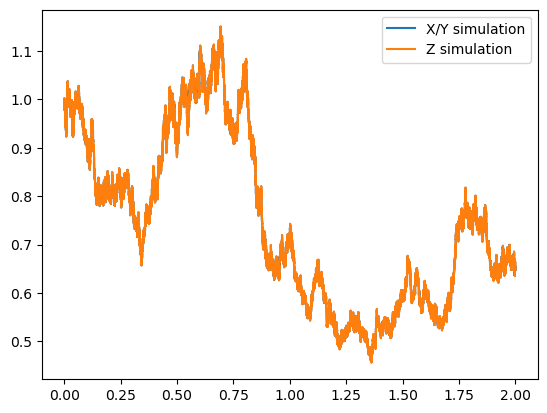

In [63]:
dW = np.random.normal(0, np.sqrt(dt), ts.shape[0])
dW_ = dW[:-1]

dV = np.random.normal(0, np.sqrt(dt), ts.shape[0])
dV_ = dV[:-1]

# X and Y simulations
'''
X = np.ones(ts.shape[0]) * x0
X[1:] = alpha * X[:-1] * dt + sigma * X[:-1] * dW_
X = np.cumsum(X)

Y = np.ones(ts.shape[0]) * y0
Y[1:] = gamma * Y[:-1] * dt + delta * Y[:-1] * dV_
Y = np.cumsum(Y)
'''

X = np.ones(ts.shape[0]) * x0
Y = np.ones(ts.shape[0]) * y0

for i in range(1, ts.shape[0]):
    X[i] = X[i - 1] + alpha * X[i - 1] * dt + sigma * X[i - 1] * dW[i-1] 
    Y[i] = Y[i - 1] + gamma * Y[i - 1] * dt + delta * Y[i - 1] * dV[i-1]

plt.plot(ts, X / Y, label='X/Y simulation')

'''
# Z simulation
Z = np.ones(ts.shape[0]) * (x0 / y0)
Z[1:] = (alpha - gamma + np.square(delta)) * Z[:-1] * dt + sigma * Z[:-1] * dW_ - delta * Z[:-1] * dV_
Z = np.cumsum(Z)
'''

Z = np.ones(ts.shape[0]) * (x0 / y0)
for i in range(1, ts.shape[0]):
    Z[i] = Z[i - 1] + (alpha - gamma + np.square(delta)) * Z[i - 1] * dt + sigma * Z[i - 1] * dW[i - 1] - delta * Z[i - 1] * dV[i - 1]


plt.plot(ts, Z, label='Z simulation')
plt.legend()
plt.show()

We see here that the blue and orange paths are completely the same, which means that the solution we came up with was correct.

Now we modify the above situation so that $X$ and $Y$ are both driven by the same Wiener process $W$:
$$
dX = \alpha X dt + \sigma X dW, \\
dY = \gamma Y dt + \delta Y dW.
$$
Again, set $Z = X/Y$ and find SDE for $Z$.

To use multivariate Ito's lemma, we need to remind ourselves of 2 variable, degree 2 Taylor polynomial:
$$
f(x,y) \simeq f(x_0, y_0) + f_x(x_0, y_0) dx + f_y (x_0, y_0) dy + \frac{1}{2} \left( f_xx dx^2 + f_yy dy^2 \right) + f_{xy} dx dy.
$$
Applying Ito's formula to $Z = f(X,Y) = X/Y$, we find that
$$
dZ = (\alpha - \gamma - \sigma \delta + \delta^2) Z dt + (\sigma - \delta) dW.
$$

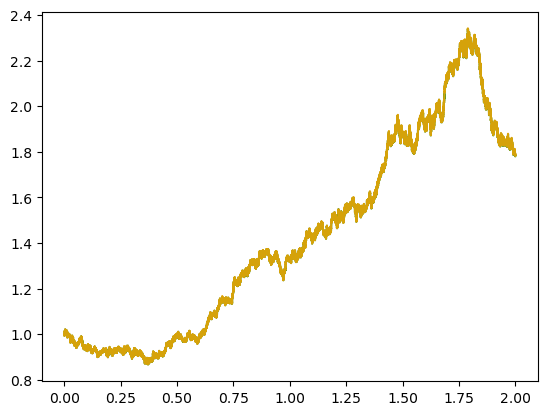

In [68]:
# Because of the errors piling up, we'll make dt smaller


dW = np.random.normal(0, np.sqrt(dt), ts.shape[0])
dW_ = dW[:-1]

# X and Y simulations

X = np.ones(ts.shape[0]) * x0
Y = np.ones(ts.shape[0]) * y0

for i in range(1, X.shape[0]):
    X[i] = X[i - 1] + alpha * X[i - 1] * dt + sigma * X[i - 1] * dW[i - 1]
    Y[i] = Y[i - 1] + gamma * Y[i - 1] * dt + delta * Y[i - 1] * dW[i - 1]


plt.plot(ts, X / Y, color='green', alpha=0.8)

# Z simulation
Z = np.ones(ts.shape[0]) * (x0 / y0)
for i in range(1, Z.shape[0]):
    Z[i] = Z[i-1] + (alpha - gamma - sigma * delta + delta * delta) * Z[i - 1] * dt + (sigma - delta) * Z[i - 1] * dW[i - 1] 

plt.plot(ts, Z, color='orange', alpha=0.8)

plt.show()

We see here that the two paths agree completely, and so our solution is indeed correct.